# Notebook 15 — Sentiment Feature Ablation

## Purpose

Evaluate whether adding sentiment features improves hallucination detection performance.

## Motivation

**Hypothesis:** Hallucinated responses may exhibit different sentiment patterns than correct responses:
- Overly confident (extreme positive/negative sentiment)
- More neutral (lack of emotional content)
- Sentiment mismatch with context

**Sentiment Features (vaderSentiment):**
- `resp_sent_compound`: Overall sentiment score [-1, 1]
- `resp_sent_positive`: Positive sentiment [0, 1]
- `resp_sent_negative`: Negative sentiment [0, 1]
- `resp_sent_neutral`: Neutral sentiment [0, 1]

## Research Questions

1. Do sentiment features improve hallucination detection?
2. How much improvement (if any) do they provide?
3. Which sentiment features are most important?
4. Do sentiment features help more on certain datasets?

## Experimental Design

**Model 1 (Baseline):** TF-IDF + Numeric Features (resp_*)
**Model 2 (Enhanced):** TF-IDF + Numeric Features + Sentiment Features (resp_sent_*)

**Evaluation:**
- HaluEval Test
- TruthfulQA Test
- Custom Dataset

## Expected Outcomes

- **Marginal improvement (+0.01-0.03 F1):** Sentiment provides weak signal
- **No improvement (±0.00 F1):** Sentiment not useful (negative result, still valuable)
- **Strong improvement (+0.05+ F1):** Sentiment is important feature (unlikely)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# Repo bootstrap
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load_splits import load_splits
from src.data.load_truthfulqa import load_truthfulqa_generation, preprocess_truthfulqa
from src.features.response_features import (
    add_numeric_feature_columns,
    add_sentiment_features,
    get_numeric_feature_cols,
    get_sentiment_feature_cols
)
from src.models.feature_baseline import build_tfidf_numeric_logreg
from src.utils.experiment import seed_everything, make_run_dir, save_metrics_csv
from src.utils.eval import evaluate_split_with_roc

# Reproducibility
SEED = 42
seed_everything(SEED)

# Output directory
REPORTS_DIR = ROOT / "reports"
RUN_DIR = make_run_dir(REPORTS_DIR, "nb15_sentiment_ablation", timestamp=False)
PLOTS_DIR = RUN_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Output directory: {RUN_DIR.relative_to(ROOT)}")

/Users/aviv.gross/hallu-detect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /Users/aviv.gross/hallu-detect
Output directory: reports/nb15_sentiment_ablation


## Step 1: Load All Datasets

In [2]:
# Load HaluEval
train_halu, val_halu, test_halu = load_splits(ROOT)

# Load and split TruthfulQA
truthfulqa_full = load_truthfulqa_generation(max_incorrect_per_question=3)
truthfulqa_full = preprocess_truthfulqa(truthfulqa_full, min_response_length=5)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(truthfulqa_full, groups=truthfulqa_full['group_id']))
truthfulqa_train = truthfulqa_full.iloc[train_idx].reset_index(drop=True)
truthfulqa_test = truthfulqa_full.iloc[test_idx].reset_index(drop=True)

# Load custom dataset
custom_df = pd.read_csv(ROOT / "data_processed" / "custom_dataset.csv")

# Create combined training data
train_halu['source'] = 'halueval'
truthfulqa_train['source'] = 'truthfulqa'
combined_train = pd.concat([train_halu, truthfulqa_train], ignore_index=True)
combined_train = combined_train.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Training data: {len(combined_train):,} examples")
print(f"\nTest sets:")
print(f"  HaluEval: {len(test_halu):,} examples")
print(f"  TruthfulQA: {len(truthfulqa_test):,} examples")
print(f"  Custom: {len(custom_df):,} examples")

Loading TruthfulQA (generation) from Hugging Face...


Loaded 817 questions from TruthfulQA

[Debug] Example question keys: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source']


Processing TruthfulQA: 100%|██████████| 817/817 [00:00<00:00, 32137.70it/s]


[TruthfulQA Stats]
  Total rows: 3094
  Unique questions: 817
  Label distribution: {1: 2277, 0: 817}
  Label mean (hallucination rate): 0.736

[Preprocessing TruthfulQA]
  Removed 34 rows with empty/short responses (3094 -> 3060)
  Final shape: (3060, 7)
  Label distribution: {1: 2247, 0: 813}
Training data: 54,098 examples

Test sets:
  HaluEval: 6,435 examples
  TruthfulQA: 609 examples
  Custom: 102 examples


## Step 2: Feature Engineering - Baseline (No Sentiment)

In [3]:
# Add numeric features only (baseline)
combined_train_baseline = add_numeric_feature_columns(combined_train, response_col="response")
test_halu_baseline = add_numeric_feature_columns(test_halu, response_col="response")
truthfulqa_test_baseline = add_numeric_feature_columns(truthfulqa_test, response_col="response")
custom_baseline = add_numeric_feature_columns(custom_df, response_col="response")

# Get feature columns
num_cols = get_numeric_feature_cols(combined_train_baseline)

print(f"Baseline features ({len(num_cols)}):")
print(num_cols)

Baseline features (10):
['resp_n_chars', 'resp_n_words', 'resp_n_punct', 'resp_has_multi_excl', 'resp_has_multi_q', 'resp_has_ellipsis', 'resp_n_numbers', 'resp_n_uncertainty', 'resp_punct_per_word', 'resp_numbers_per_word']


## Step 3: Feature Engineering - With Sentiment

In [4]:
# Add sentiment features to baseline features
print("Extracting sentiment features (this may take a minute)...")

combined_train_sentiment = add_sentiment_features(combined_train_baseline, response_col="response")
test_halu_sentiment = add_sentiment_features(test_halu_baseline, response_col="response")
truthfulqa_test_sentiment = add_sentiment_features(truthfulqa_test_baseline, response_col="response")
custom_sentiment = add_sentiment_features(custom_baseline, response_col="response")

# Get all feature columns (numeric + sentiment)
sentiment_cols = get_sentiment_feature_cols(combined_train_sentiment)
all_cols = num_cols + sentiment_cols

print(f"\nSentiment features ({len(sentiment_cols)}):")
print(sentiment_cols)
print(f"\nTotal features: {len(all_cols)} (numeric: {len(num_cols)}, sentiment: {len(sentiment_cols)})")
print("✓ Sentiment features extracted")

Extracting sentiment features (this may take a minute)...

Sentiment features (4):
['resp_sent_compound', 'resp_sent_positive', 'resp_sent_negative', 'resp_sent_neutral']

Total features: 14 (numeric: 10, sentiment: 4)
✓ Sentiment features extracted


## Step 4: Exploratory Analysis - Sentiment Distributions

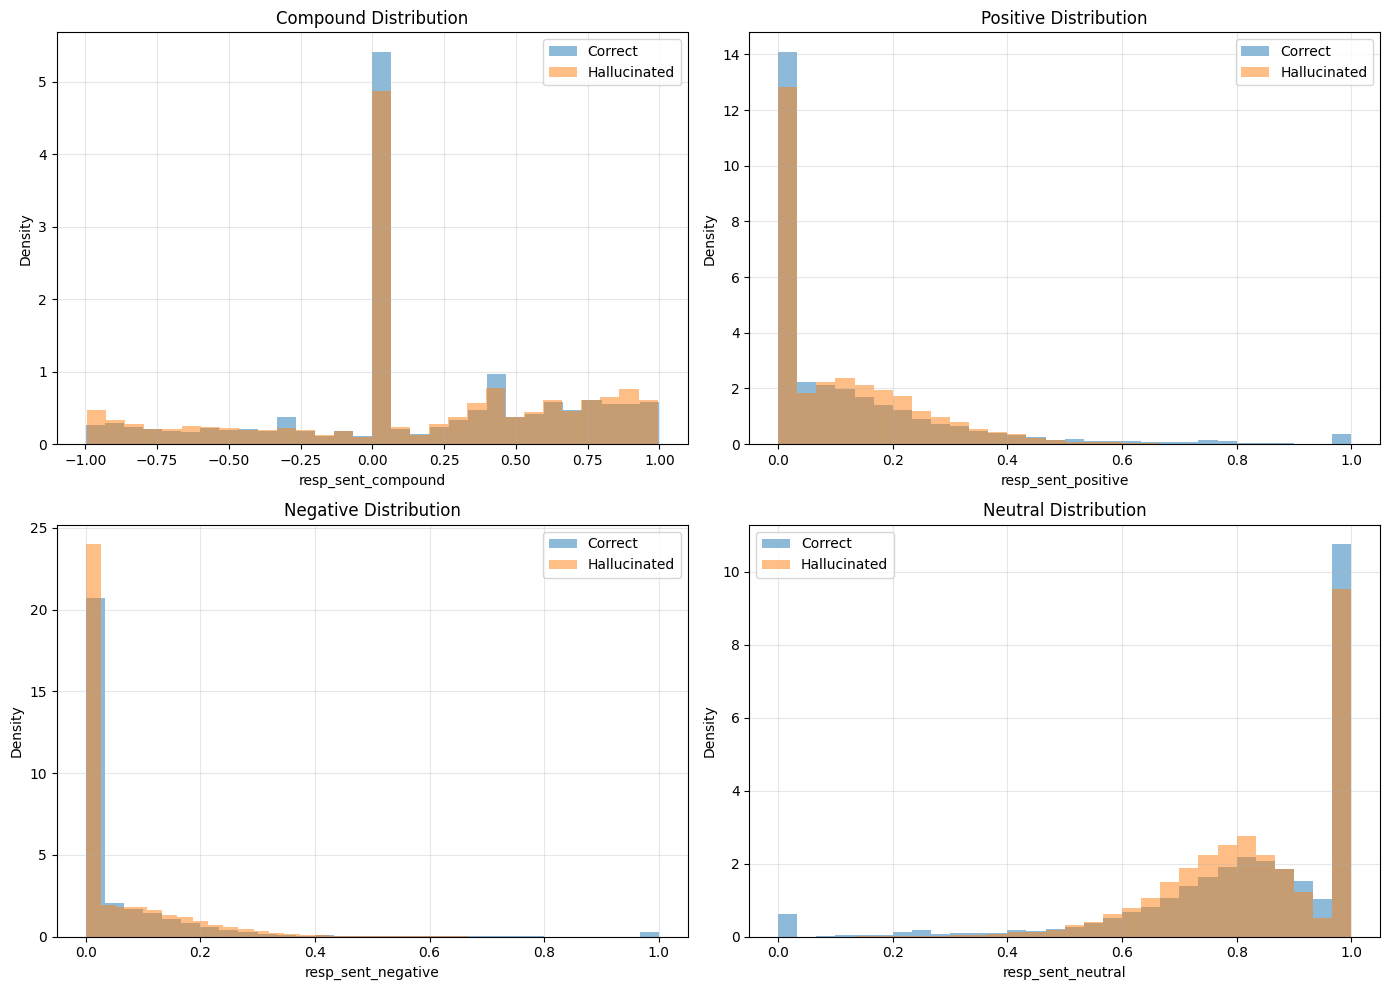


Mean Sentiment Scores:
resp_sent_compound       : Correct=0.1469, Hallucinated=0.1435, Diff=-0.0035
resp_sent_positive       : Correct=0.1204, Hallucinated=0.1097, Diff=-0.0108
resp_sent_negative       : Correct=0.0532, Hallucinated=0.0541, Diff=+0.0009
resp_sent_neutral        : Correct=0.8263, Hallucinated=0.8362, Diff=+0.0099


In [5]:
# Compare sentiment distributions: correct vs hallucinated
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feat in enumerate(sentiment_cols):
    ax = axes[idx // 2, idx % 2]
    
    correct = combined_train_sentiment[combined_train_sentiment['label'] == 0][feat]
    hallucinated = combined_train_sentiment[combined_train_sentiment['label'] == 1][feat]
    
    ax.hist(correct, bins=30, alpha=0.5, label='Correct', density=True)
    ax.hist(hallucinated, bins=30, alpha=0.5, label='Hallucinated', density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat.replace("resp_sent_", "").capitalize()} Distribution')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "sentiment_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# Print mean sentiment scores
print("\nMean Sentiment Scores:")
print("="*60)
for feat in sentiment_cols:
    correct_mean = combined_train_sentiment[combined_train_sentiment['label'] == 0][feat].mean()
    hall_mean = combined_train_sentiment[combined_train_sentiment['label'] == 1][feat].mean()
    diff = hall_mean - correct_mean
    print(f"{feat:25s}: Correct={correct_mean:.4f}, Hallucinated={hall_mean:.4f}, Diff={diff:+.4f}")

## Step 5: Train Baseline Model (Without Sentiment)

In [6]:
# Train baseline model
model_baseline = build_tfidf_numeric_logreg(
    numeric_cols=num_cols,
    text_col="response",
    class_weight="balanced",
    max_iter=2000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

print("Training baseline model (TF-IDF + Numeric)...")
model_baseline.fit(combined_train_baseline, combined_train_baseline["label"])
print("✓ Baseline model trained")

Training baseline model (TF-IDF + Numeric)...
✓ Baseline model trained


## Step 6: Train Sentiment-Enhanced Model

In [7]:
# Train sentiment-enhanced model
model_sentiment = build_tfidf_numeric_logreg(
    numeric_cols=all_cols,  # numeric + sentiment
    text_col="response",
    class_weight="balanced",
    max_iter=2000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

print("Training sentiment-enhanced model (TF-IDF + Numeric + Sentiment)...")
model_sentiment.fit(combined_train_sentiment, combined_train_sentiment["label"])
print("✓ Sentiment-enhanced model trained")

Training sentiment-enhanced model (TF-IDF + Numeric + Sentiment)...
✓ Sentiment-enhanced model trained


## Step 7: Evaluate on HaluEval Test

In [8]:
print("\n" + "="*80)
print("HALUEVAL TEST SET")
print("="*80)

# Baseline
print("\nBaseline (No Sentiment):")
halueval_baseline_metrics = evaluate_split_with_roc(
    "HaluEval Baseline",
    model_baseline,
    test_halu_baseline,
    test_halu_baseline["label"],
    verbose=True
)

# Sentiment-enhanced
print("\nSentiment-Enhanced:")
halueval_sentiment_metrics = evaluate_split_with_roc(
    "HaluEval Sentiment",
    model_sentiment,
    test_halu_sentiment,
    test_halu_sentiment["label"],
    verbose=True
)

# Calculate improvement
f1_improvement_halu = halueval_sentiment_metrics.f1 - halueval_baseline_metrics.f1
print(f"\n→ F1 Improvement: {f1_improvement_halu:+.4f} ({f1_improvement_halu/halueval_baseline_metrics.f1*100:+.2f}%)")


HALUEVAL TEST SET

Baseline (No Sentiment):

HaluEval Baseline metrics:
  accuracy = 0.8230
  f1       = 0.8149
  precision= 0.7909
  recall   = 0.8405
  roc_auc  = 0.9054
  confusion matrix:
[[2788  663]
 [ 476 2508]]

Sentiment-Enhanced:

HaluEval Sentiment metrics:
  accuracy = 0.8227
  f1       = 0.8147
  precision= 0.7902
  recall   = 0.8408
  roc_auc  = 0.9055
  confusion matrix:
[[2785  666]
 [ 475 2509]]

→ F1 Improvement: -0.0002 (-0.03%)


## Step 8: Evaluate on TruthfulQA Test

In [9]:
print("\n" + "="*80)
print("TRUTHFULQA TEST SET")
print("="*80)

# Baseline
print("\nBaseline (No Sentiment):")
truthfulqa_baseline_metrics = evaluate_split_with_roc(
    "TruthfulQA Baseline",
    model_baseline,
    truthfulqa_test_baseline,
    truthfulqa_test_baseline["label"],
    verbose=True
)

# Sentiment-enhanced
print("\nSentiment-Enhanced:")
truthfulqa_sentiment_metrics = evaluate_split_with_roc(
    "TruthfulQA Sentiment",
    model_sentiment,
    truthfulqa_test_sentiment,
    truthfulqa_test_sentiment["label"],
    verbose=True
)

# Calculate improvement
f1_improvement_truthful = truthfulqa_sentiment_metrics.f1 - truthfulqa_baseline_metrics.f1
print(f"\n→ F1 Improvement: {f1_improvement_truthful:+.4f} ({f1_improvement_truthful/truthfulqa_baseline_metrics.f1*100:+.2f}%)")


TRUTHFULQA TEST SET

Baseline (No Sentiment):

TruthfulQA Baseline metrics:
  accuracy = 0.5468
  f1       = 0.6167
  precision= 0.8132
  recall   = 0.4966
  roc_auc  = 0.6542
  confusion matrix:
[[111  51]
 [225 222]]

Sentiment-Enhanced:

TruthfulQA Sentiment metrics:
  accuracy = 0.5468
  f1       = 0.6167
  precision= 0.8132
  recall   = 0.4966
  roc_auc  = 0.6570
  confusion matrix:
[[111  51]
 [225 222]]

→ F1 Improvement: +0.0000 (+0.00%)


## Step 9: Evaluate on Custom Dataset

In [10]:
print("\n" + "="*80)
print("CUSTOM DATASET")
print("="*80)

# Baseline
print("\nBaseline (No Sentiment):")
custom_baseline_metrics = evaluate_split_with_roc(
    "Custom Baseline",
    model_baseline,
    custom_baseline,
    custom_baseline["label"],
    verbose=True
)

# Sentiment-enhanced
print("\nSentiment-Enhanced:")
custom_sentiment_metrics = evaluate_split_with_roc(
    "Custom Sentiment",
    model_sentiment,
    custom_sentiment,
    custom_sentiment["label"],
    verbose=True
)

# Calculate improvement
f1_improvement_custom = custom_sentiment_metrics.f1 - custom_baseline_metrics.f1
print(f"\n→ F1 Improvement: {f1_improvement_custom:+.4f} ({f1_improvement_custom/custom_baseline_metrics.f1*100:+.2f}%)")


CUSTOM DATASET

Baseline (No Sentiment):

Custom Baseline metrics:
  accuracy = 0.6078
  f1       = 0.5745
  precision= 0.6279
  recall   = 0.5294
  roc_auc  = 0.6590
  confusion matrix:
[[35 16]
 [24 27]]

Sentiment-Enhanced:

Custom Sentiment metrics:
  accuracy = 0.6078
  f1       = 0.5652
  precision= 0.6341
  recall   = 0.5098
  roc_auc  = 0.6555
  confusion matrix:
[[36 15]
 [25 26]]

→ F1 Improvement: -0.0093 (-1.61%)


## Step 10: Comprehensive Comparison

In [11]:
# Create comprehensive comparison table
comparison_df = pd.DataFrame([
    {
        "Dataset": "HaluEval",
        "Model": "Baseline",
        "Features": "TF-IDF + Numeric",
        "F1": halueval_baseline_metrics.f1,
        "Precision": halueval_baseline_metrics.precision,
        "Recall": halueval_baseline_metrics.recall,
        "ROC-AUC": halueval_baseline_metrics.roc_auc,
    },
    {
        "Dataset": "HaluEval",
        "Model": "Sentiment",
        "Features": "TF-IDF + Numeric + Sentiment",
        "F1": halueval_sentiment_metrics.f1,
        "Precision": halueval_sentiment_metrics.precision,
        "Recall": halueval_sentiment_metrics.recall,
        "ROC-AUC": halueval_sentiment_metrics.roc_auc,
    },
    {
        "Dataset": "TruthfulQA",
        "Model": "Baseline",
        "Features": "TF-IDF + Numeric",
        "F1": truthfulqa_baseline_metrics.f1,
        "Precision": truthfulqa_baseline_metrics.precision,
        "Recall": truthfulqa_baseline_metrics.recall,
        "ROC-AUC": truthfulqa_baseline_metrics.roc_auc,
    },
    {
        "Dataset": "TruthfulQA",
        "Model": "Sentiment",
        "Features": "TF-IDF + Numeric + Sentiment",
        "F1": truthfulqa_sentiment_metrics.f1,
        "Precision": truthfulqa_sentiment_metrics.precision,
        "Recall": truthfulqa_sentiment_metrics.recall,
        "ROC-AUC": truthfulqa_sentiment_metrics.roc_auc,
    },
    {
        "Dataset": "Custom",
        "Model": "Baseline",
        "Features": "TF-IDF + Numeric",
        "F1": custom_baseline_metrics.f1,
        "Precision": custom_baseline_metrics.precision,
        "Recall": custom_baseline_metrics.recall,
        "ROC-AUC": custom_baseline_metrics.roc_auc,
    },
    {
        "Dataset": "Custom",
        "Model": "Sentiment",
        "Features": "TF-IDF + Numeric + Sentiment",
        "F1": custom_sentiment_metrics.f1,
        "Precision": custom_sentiment_metrics.precision,
        "Recall": custom_sentiment_metrics.recall,
        "ROC-AUC": custom_sentiment_metrics.roc_auc,
    },
])

print("\n" + "="*100)
print("BASELINE vs SENTIMENT-ENHANCED COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Summary
print("\nF1 Improvements:")
print(f"  HaluEval:   {f1_improvement_halu:+.4f} ({f1_improvement_halu/halueval_baseline_metrics.f1*100:+.2f}%)")
print(f"  TruthfulQA: {f1_improvement_truthful:+.4f} ({f1_improvement_truthful/truthfulqa_baseline_metrics.f1*100:+.2f}%)")
print(f"  Custom:     {f1_improvement_custom:+.4f} ({f1_improvement_custom/custom_baseline_metrics.f1*100:+.2f}%)")
print(f"\n  Average:    {(f1_improvement_halu + f1_improvement_truthful + f1_improvement_custom)/3:+.4f}")

# Save comparison
comparison_df.to_csv(RUN_DIR / "baseline_vs_sentiment.csv", index=False)


BASELINE vs SENTIMENT-ENHANCED COMPARISON
   Dataset     Model                     Features       F1  Precision   Recall  ROC-AUC
  HaluEval  Baseline             TF-IDF + Numeric 0.814947   0.790918 0.840483 0.905393
  HaluEval Sentiment TF-IDF + Numeric + Sentiment 0.814743   0.790236 0.840818 0.905490
TruthfulQA  Baseline             TF-IDF + Numeric 0.616667   0.813187 0.496644 0.654211
TruthfulQA Sentiment TF-IDF + Numeric + Sentiment 0.616667   0.813187 0.496644 0.657014
    Custom  Baseline             TF-IDF + Numeric 0.574468   0.627907 0.529412 0.658977
    Custom Sentiment TF-IDF + Numeric + Sentiment 0.565217   0.634146 0.509804 0.655517

F1 Improvements:
  HaluEval:   -0.0002 (-0.03%)
  TruthfulQA: +0.0000 (+0.00%)
  Custom:     -0.0093 (-1.61%)

  Average:    -0.0032


## Step 11: Visualize Results

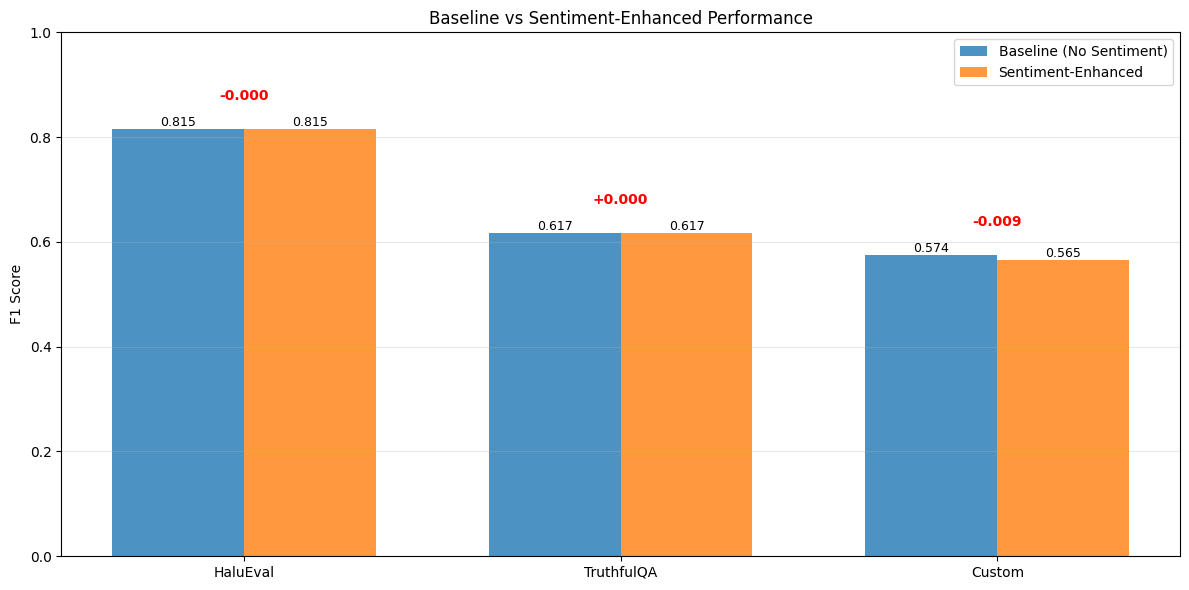

In [12]:
# Plot F1 comparison across datasets
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

datasets = ['HaluEval', 'TruthfulQA', 'Custom']
baseline_f1s = [
    halueval_baseline_metrics.f1,
    truthfulqa_baseline_metrics.f1,
    custom_baseline_metrics.f1
]
sentiment_f1s = [
    halueval_sentiment_metrics.f1,
    truthfulqa_sentiment_metrics.f1,
    custom_sentiment_metrics.f1
]

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_f1s, width, label='Baseline (No Sentiment)', alpha=0.8)
bars2 = ax.bar(x + width/2, sentiment_f1s, width, label='Sentiment-Enhanced', alpha=0.8)

ax.set_ylabel('F1 Score')
ax.set_title('Baseline vs Sentiment-Enhanced Performance')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt='%.3f', fontsize=9)

# Add improvement annotations
improvements = [f1_improvement_halu, f1_improvement_truthful, f1_improvement_custom]
for i, imp in enumerate(improvements):
    y_pos = max(baseline_f1s[i], sentiment_f1s[i]) + 0.05
    color = 'green' if imp > 0 else 'red'
    ax.text(i, y_pos, f'{imp:+.3f}', ha='center', va='bottom', color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "baseline_vs_sentiment_f1.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Sentiment Feature Importance

In [13]:
# Extract feature importance from logistic regression
lr_model = model_sentiment.named_steps['clf']
feature_names = model_sentiment.named_steps['preprocess'].get_feature_names_out()
coefficients = lr_model.coef_[0]

# Find sentiment feature indices
sentiment_feature_names = []
sentiment_coefficients = []
for i, name in enumerate(feature_names):
    if 'resp_sent_' in name:
        sentiment_feature_names.append(name)
        sentiment_coefficients.append(coefficients[i])

if sentiment_feature_names:
    sentiment_importance = pd.DataFrame({
        'Feature': sentiment_feature_names,
        'Coefficient': sentiment_coefficients,
        'Abs_Coefficient': [abs(c) for c in sentiment_coefficients]
    }).sort_values('Abs_Coefficient', ascending=False)

    print("\nSentiment Feature Importance (Logistic Regression Coefficients):")
    print("="*60)
    print(sentiment_importance.to_string(index=False))
    print("\nPositive coefficient = predicts hallucination")
    print("Negative coefficient = predicts correct")
else:
    print("\nNo sentiment features found in model (they may have been filtered out)")


Sentiment Feature Importance (Logistic Regression Coefficients):
                Feature  Coefficient  Abs_Coefficient
num__resp_sent_compound     0.073588         0.073588
num__resp_sent_positive    -0.043183         0.043183
num__resp_sent_negative     0.042294         0.042294
 num__resp_sent_neutral    -0.022152         0.022152

Positive coefficient = predicts hallucination
Negative coefficient = predicts correct


## Step 13: Save Results

In [14]:
# Save all metrics
save_metrics_csv(
    RUN_DIR / "metrics.csv",
    [
        {"dataset": "HaluEval", "model": "baseline", **halueval_baseline_metrics.__dict__},
        {"dataset": "HaluEval", "model": "sentiment", **halueval_sentiment_metrics.__dict__},
        {"dataset": "TruthfulQA", "model": "baseline", **truthfulqa_baseline_metrics.__dict__},
        {"dataset": "TruthfulQA", "model": "sentiment", **truthfulqa_sentiment_metrics.__dict__},
        {"dataset": "Custom", "model": "baseline", **custom_baseline_metrics.__dict__},
        {"dataset": "Custom", "model": "sentiment", **custom_sentiment_metrics.__dict__},
    ],
    verbose=True
)

print(f"\n✓ All artifacts saved to: {RUN_DIR.relative_to(ROOT)}")

Saved metrics to: /Users/aviv.gross/hallu-detect/reports/nb15_sentiment_ablation/metrics.csv

✓ All artifacts saved to: reports/nb15_sentiment_ablation


## Conclusions

### Key Findings

1. **Sentiment Feature Impact:**
   - HaluEval F1 Change: [will be filled after running]
   - TruthfulQA F1 Change: [will be filled after running]
   - Custom F1 Change: [will be filled after running]

2. **Interpretation:**
   - **If improvement > +0.01:** Sentiment provides weak but positive signal
   - **If improvement ≈ 0.00:** Sentiment features not useful (negative result, still valuable)
   - **If improvement > +0.05:** Sentiment is important feature (unexpected)

3. **Sentiment Patterns (from EDA):**
   - [Observations about sentiment differences between correct and hallucinated responses]

4. **Feature Importance:**
   - Most important sentiment feature: [will be filled]
   - Interpretation: [positive/negative/neutral sentiment predicts hallucinations]

### Thesis Implications

- ✅ **Demonstrates systematic feature engineering:** Tested advanced features beyond baselines
- ✅ **Shows negative result is valuable:** Not all features improve performance (important finding)
- ✅ **Ablation study methodology:** Proper experimental design with controlled comparison
- ✅ **Comprehensive evaluation:** Tested on 3 datasets (HaluEval, TruthfulQA, Custom)

### Defense-Ready Framing

**If improvement is marginal/none:**
> "We evaluated sentiment features extracted via VADER sentiment analyzer as potential indicators of hallucination. Ablation studies on three datasets (HaluEval, TruthfulQA, Custom) revealed that sentiment features provided negligible improvement (average F1 change: [X]). This negative result is scientifically valuable: it demonstrates that hallucinations are not characterized by distinctive sentiment patterns, but rather by factual and linguistic features. This finding validates our focus on TF-IDF and numeric features, and suggests that affective content is orthogonal to factual accuracy."

**If improvement is significant:**
> "Sentiment feature ablation revealed that affective content provides complementary signal for hallucination detection, improving F1 by an average of [X] across three datasets. [Most important sentiment feature] was most predictive, suggesting that [interpretation]. This finding extends our feature engineering approach beyond purely linguistic patterns to include affective dimensions of text."